In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
import yaml
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import ComplementNB

In [2]:
data1 = pd.read_csv('test.csv', encoding='utf-8')
data1['type'] = 'test'

data2 = pd.read_csv('train.csv', encoding='utf-8')
data2['type'] = 'train'

data3 = pd.read_csv('valid.csv', encoding='utf-8')
data3['valid'] = 'valid'

datas = [data1, data2, data3]
data = pd.concat(datas, ignore_index=True)

In [3]:
data.head(1)
rows, cols = data.shape

print(f"Строк: {rows}")
print(f"Столбцов: {cols}")

Строк: 22962
Столбцов: 18


In [ ]:
data['sum_true'] = data['true_counts'] + data['mostly_true_counts'] + data['half_true_counts']
data.head(1)


,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,1,3,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3


In [5]:
data['sum_false'] = data['mostly_false_counts'] + data['false_counts'] + data['pants_on_fire_counts']
data.head(1)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,1,3,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21


In [6]:
data['result'] = data['sum_true'] > data['sum_false']


data.head(4)
rows, cols = data.shape

print(f"Строк: {rows}")
print(f"Столбцов: {cols}")

Строк: 22962
Столбцов: 21


In [7]:
data.groupby('result').agg({'context': 'count'})

,context
result,
False,13128
True,9680


<BarContainer object of 6 artists>

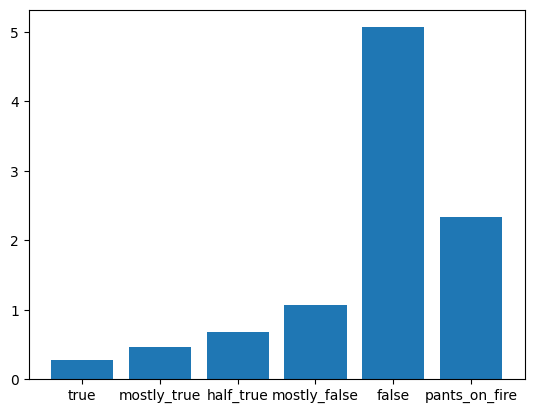

In [8]:
graf = {'true':data['true_counts'].sum() / 1000000,
'mostly_true':data['mostly_true_counts'].sum() / 1000000,
'half_true':data['half_true_counts'].sum() / 1000000,
'mostly_false':data['mostly_false_counts'].sum() / 1000000,
'false':data['false_counts'].sum() / 1000000,
'pants_on_fire':data['pants_on_fire_counts'].sum() / 1000000}

labels = list(graf.keys())
values = list(graf.values())


plt.bar(labels, values)

In [9]:
graf

{'true': np.float64(0.278931),
 'mostly_true': np.float64(0.469435),
 'half_true': np.float64(0.682852),
 'mostly_false': np.float64(1.065637),
 'false': np.float64(5.069291),
 'pants_on_fire': np.float64(2.328234)}

In [10]:
data['Words_Statement'] = data['statement'].str.split().str.len()
data.head(3)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result,Words_Statement
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,1410,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False,6
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,711,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False,13


In [11]:
data['Words_Statement'].median()

np.float64(16.0)

In [12]:
data_state = data.groupby(['state_info']).agg({'context': 'count'})
data_state

,context
state_info,
arizona,121
california,353
colorado,50
florida,1709
georgia,976
illinois,210
iowa,81
michigan,71
missouri,194


In [13]:
data_state.sort_values(by='context', ascending=False).head(7)

,context
state_info,
national,6045
wisconsin,1834
florida,1709
texas,1649
georgia,976
virginia,670
ohio,652


In [14]:
data.head(5)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,false_counts,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result,Words_Statement
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,15,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,1410,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False,6
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,711,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False,13
3,9897,1,"It will cost $50,000 per enrollee in Obamacare...","January 27, 2015",health care;taxes;punditfact,stuart varney,Stuart Varney is a British business journalist...,NaN,0,0,...,1,0,"an interview on Fox News' ""America's Newsroom""","Varney said that it will cost taxpayers $50,00...",test,NaN,0,2,False,13
4,3855,3,The Federal Register - which houses all Washin...,"June 14, 2011",regulation,randy forbes,Randy Forbes is from Chesapeake and represents...,virginia,5,3,...,0,0,a statement,To recap: To argue that regulation is out of c...,test,NaN,12,1,True,23


In [15]:
data.to_csv('data.csv')

In [16]:
data['Words_Justification'] = data['justification'].str.split().str.len()
data.head(4)

,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,pants_on_fire_counts,context,justification,type,valid,sum_true,sum_false,result,Words_Statement,Words_Justification
0,21750,1,Three doctors from the same hospital 'die sudd...,"July 28, 2022",facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,3,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22,90
1,18173,0,Say Joe Biden is a pedophile.,"July 17, 2020",facebook fact-checks,facebook posts,Posters on Facebook and other social media net...,NaN,24,50,...,570,Facebook posts,Social media users that Biden is a pedophile....,test,NaN,182,2225,False,6,47
2,22673,1,A photo shows President Joe Biden and Ukrainia...,"February 20, 2023",facebook fact-checks;ukraine,viral image,"Graphics, pictures and charts shared on social...",NaN,4,13,...,331,an Instagram post,The image appears to show Biden and Zelenskyy ...,test,NaN,52,1095,False,13,82
3,9897,1,"It will cost $50,000 per enrollee in Obamacare...","January 27, 2015",health care;taxes;punditfact,stuart varney,Stuart Varney is a British business journalist...,NaN,0,0,...,0,"an interview on Fox News' ""America's Newsroom""","Varney said that it will cost taxpayers $50,00...",test,NaN,0,2,False,13,112


In [17]:
data['Words_Justification'].median()

np.float64(88.0)

In [18]:

data['date'] = pd.to_datetime(data['date'])

data['year'] = data['date'].dt.year


In [19]:
exclude_years = [2000, 2002]
data = data[~data['year'].isin(exclude_years)]

data.groupby(['year']).agg({'id': 'count'})

,id
year,
2007,247
2008,552
2009,449
2010,1570
2011,1924
2012,1938
2013,1418
2014,1545
2015,1289


In [ ]:

data['statement'] = data['statement'].fillna('')


vectorizer = CountVectorizer()

vectorizer.fit(data['statement'])
bow_matrix = vectorizer.transform(data[data['type'] == 'train']['statement'])

In [21]:
x = bow_matrix
y = data[data['type'] == 'train']['result'].astype(int)

model = ComplementNB(norm=False)

model.fit(x, data[data['type'] == 'train']['label'])

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueOnly used in edge case with a single class in the training set.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. Not used.",None
,"norm norm: bool, default=FalseWhether or not a second normalization of the weights is performed. Thedefault behavior mirrors the implementations found in Mahout and Weka,which do not follow the full algorithm described in Table 9 of thepaper.",False


In [ ]:

data['statement'] = data['statement'].fillna('')


bow_matrix_test = vectorizer.transform(data[data['type'] == 'test']['statement'])

In [23]:
x = bow_matrix_test

y_predict = model.predict(x)
y_predict


array([1, 0, 1, ..., 3, 2, 1], shape=(2296,))

In [26]:
f1 = f1_score(data[data['type'] == 'test']['label'].astype(int), y_predict, average='macro')
print(f1)
f1_result({"model": "ComplementNB", 'f1_score': f1, 'norm': False, 'n_gramm': '(1, 2)'})

0.2847720654059192


NameError: name 'f1_result' is not defined

In [27]:

def f1_result(data):
    try:
        with open('results.yaml', 'r', encoding='utf-8') as f:
            yaml_data = yaml.safe_load(f) or []
    except FileNotFoundError:
        yaml_data = []    
    yaml_data.append(data)
    
    with open('results.yaml', 'w', encoding='utf-8') as f:
        yaml.dump(yaml_data, f, allow_unicode=True, default_flow_style=False, sort_keys=False)

In [30]:
rows, cols = data.shape

print(f"Строк: {rows}")
print(f"Столбцов: {cols}")
data.head(1)

Строк: 22960
Столбцов: 24


,id,label,statement,date,subject,speaker,speaker_description,state_info,true_counts,mostly_true_counts,...,context,justification,type,valid,sum_true,sum_false,result,Words_Statement,Words_Justification,year
0,21750,1,Three doctors from the same hospital 'die sudd...,2022-07-28,facebook fact-checks;coronavirus,the gateway pundit,The Gateway Pundit is a conservative website.,NaN,1,1,...,a post,""" Segall’s obituary said he died ""after a un...",test,NaN,3,21,False,22,90,2022


In [32]:
data[['true_counts', 'mostly_true_counts', 'half_true_counts', 'mostly_false_counts', 'false_counts', 'pants_on_fire_counts']].corr()


,true_counts,mostly_true_counts,half_true_counts,mostly_false_counts,false_counts,pants_on_fire_counts
true_counts,1.000000,0.947728,0.803200,0.405250,0.193110,0.161181
mostly_true_counts,0.947728,1.000000,0.918494,0.594334,0.347202,0.320702
half_true_counts,0.803200,0.918494,1.000000,0.852920,0.666698,0.627814
mostly_false_counts,0.405250,0.594334,0.852920,1.000000,0.905006,0.868554
false_counts,0.193110,0.347202,0.666698,0.905006,1.000000,0.956945
pants_on_fire_counts,0.161181,0.320702,0.627814,0.868554,0.956945,1.000000
